In [111]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
import plotly.graph_objects as go
import sys
sys.path.append("../")
from utils import metrics
from scipy import stats
from tqdm import tqdm
from background_removal.main_background_removal import main_background_removal

In [112]:
def compute_grad_magnitude(img):
    grad_x = cv2.Sobel(img, ddepth=cv2.CV_64F, dx=1, dy=0)
    grad_y = cv2.Sobel(img, ddepth=cv2.CV_64F, dx=0, dy=1)
    grad_module = cv2.magnitude(grad_x, grad_y)
    return np.uint8(grad_module)

In [113]:
def get_discriminative_mask(img):
    hsv_image = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    h, s, v = cv2.split(hsv_image)
    edges_s = compute_grad_magnitude(s)

    mask_s = edges_s
    mask_s[mask_s < 75] = 0
    mask_s[mask_s != 0] = 255

    mask = mask_s
    

    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_RECT, ksize=(10, 5)))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_RECT, ksize=(5, 10)))

    # plt.imshow(mask,cmap='gray')
    # plt.show()

    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask)

    #For each label except background, get area and pick the two largest (possible two paintings)
    component_info = [(i, stats[i, 4]) for i in range(1, num_labels)]
    component_info.sort(key=lambda c: c[1], reverse=True)
    top_two_labels = [c[0] for c in component_info[:2]]

    new_mask = np.zeros_like(mask)

    for label in top_two_labels:
        
        # Create a mask of only this component
        ys, xs = np.where(labels == label)
        points = np.column_stack((xs, ys))
        
        # Get rotated rectangle from these points
        rect = cv2.minAreaRect(points)
        box = cv2.boxPoints(rect).astype(int)
        
        # Fill the rectangle in the mask
        cv2.fillPoly(new_mask, [box], 255)
        
    # plt.imshow(new_mask,cmap='gray')
    # plt.show()  
    
    return new_mask

def get_masks(img) -> list:
    
    AREA_THRESHOLD = (0.2*img.shape[0]) * (0.2*img.shape[1])
    discriminative_mask = get_discriminative_mask(img)

    # Check if there is more than one painting (big area)
    num_labels, _, stats, _ = cv2.connectedComponentsWithStats(discriminative_mask)
    small_areas = np.sum(stats[1:, 4] < AREA_THRESHOLD)
    # print(num_labels - small_areas - 1)
    if num_labels - small_areas - 1 > 1:
        
        #Sort stats from left painting to right painting (in case there are more than 2 in the future)
        stats_no_background = stats[1:]
        stats_no_background = stats_no_background[np.argsort(stats_no_background[:, 0])]
        
        #Compute their distances to get their image slice
        left_painting_x = stats_no_background[0, 0] + stats_no_background[0, 2]
        right_painting_x = stats_no_background[1, 0]
        distance = right_painting_x - left_painting_x
        middle_pos = left_painting_x + distance//2

        
        left_painting = img[:, 0:middle_pos]
        right_painting = img[:, middle_pos:]
        
        _, left_mask = main_background_removal(left_painting)
        _, right_mask = main_background_removal(right_painting)
        return [left_mask, right_mask]

    # print("Doing single mask")
    # plt.imshow(img)
    # plt.show()
    _, mask = main_background_removal(img)
    return [mask]

In [114]:
def has_impulse_noise(img, diff_threshold=60, ratio_threshold=0.01):
    median = cv2.medianBlur(img, 3)
    diff = cv2.absdiff(img, median)
    noisy_pixels = np.any(diff > diff_threshold, axis=2)
    noise_ratio = np.sum(noisy_pixels) / noisy_pixels.size
    return noise_ratio > ratio_threshold

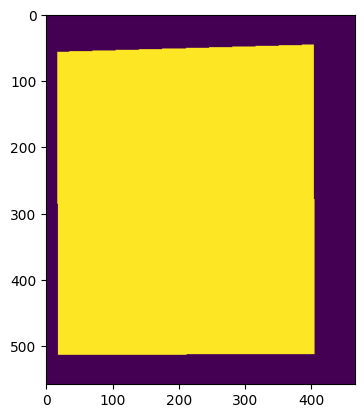

In [115]:
img1 = cv2.imread("../data/qsd2_w3/00022.jpg", cv2.IMREAD_UNCHANGED)
if has_impulse_noise(img1):
    img1 = cv2.medianBlur(img1, 3)
masks = get_masks(img1)
_, mask = main_background_removal(img1)
plt.imshow(mask)
plt.show()

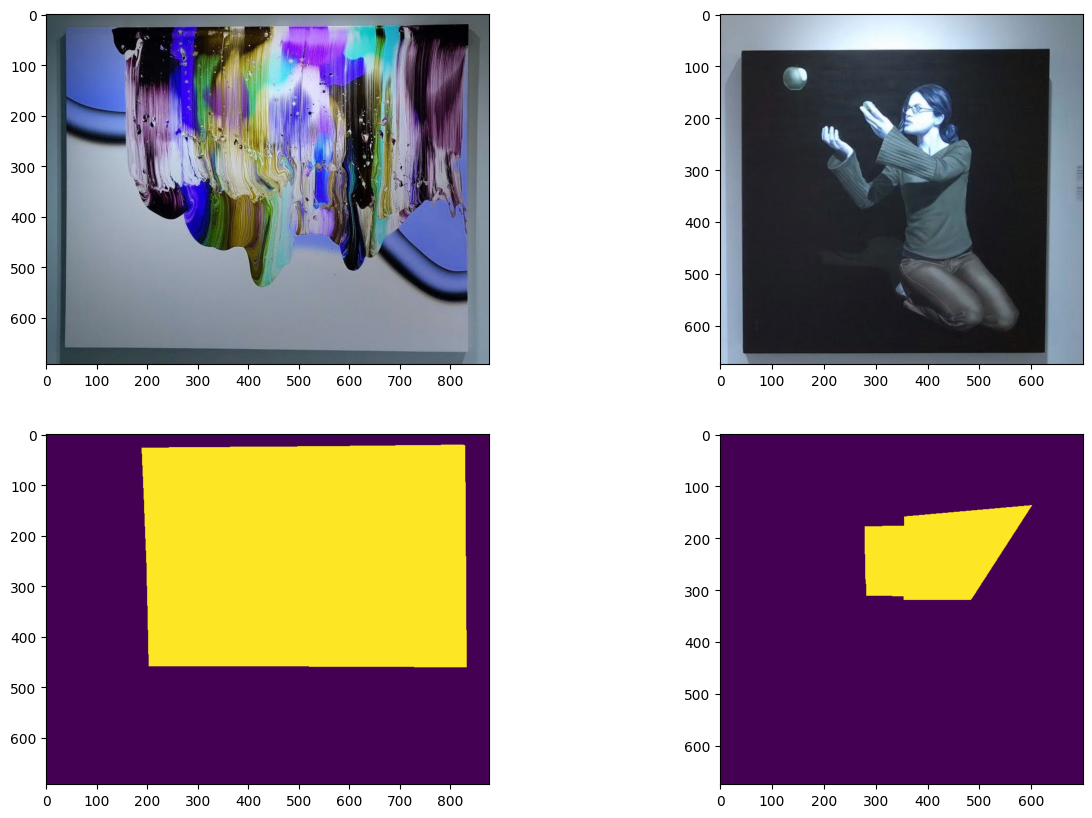

In [116]:
img1 = cv2.imread("../data/qsd2_w3/00021.jpg", cv2.IMREAD_UNCHANGED)
img2 = cv2.imread("../data/qsd2_w3/00024.jpg", cv2.IMREAD_UNCHANGED)
f, ax = plt.subplots(2, 2, figsize=(15,10))
ax[0][0].imshow(img1)
_, mask = main_background_removal(img1)
ax[1][0].imshow(mask)
ax[0][1].imshow(img2)
_, mask = main_background_removal(img2)
ax[1][1].imshow(mask)
plt.show()

  0%|          | 0/30 [00:00<?, ?it/s]

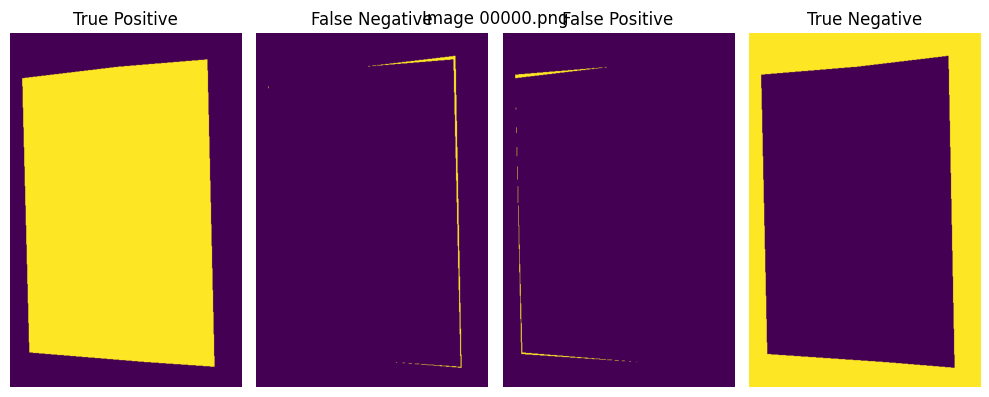

  3%|▎         | 1/30 [00:01<00:38,  1.34s/it]

Precision: 0.9926754976269746
Recall: 0.9878286041899678
F_score: 0.9902461200002827


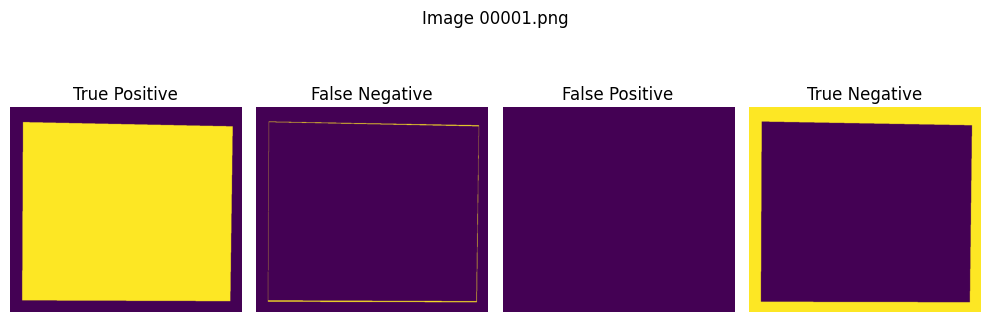

  7%|▋         | 2/30 [00:03<00:45,  1.62s/it]

Precision: 1.0
Recall: 0.9857890422342254
F_score: 0.9928436719794839


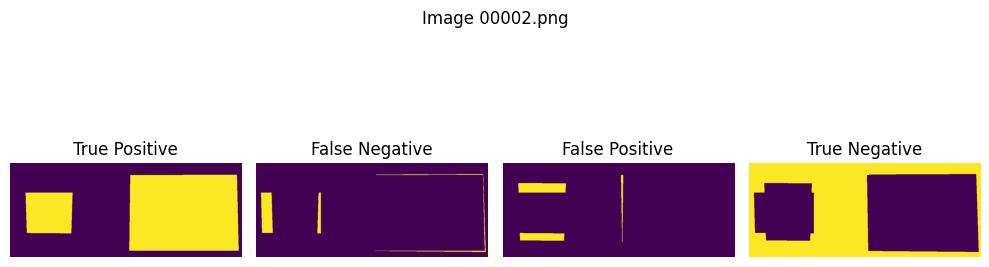

 10%|█         | 3/30 [00:04<00:44,  1.64s/it]

Precision: 0.9215721247619432
Recall: 0.9308915920331506
F_score: 0.9262084159761296


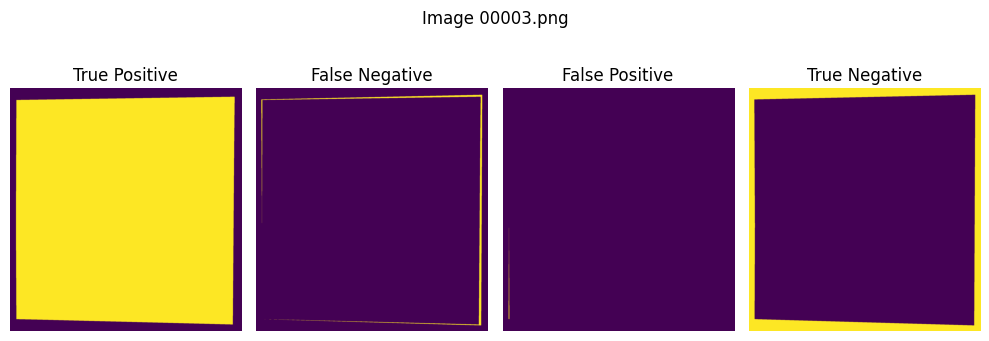

 13%|█▎        | 4/30 [00:10<01:19,  3.05s/it]

Precision: 0.9992278778993394
Recall: 0.9818903671399699
F_score: 0.9904832589814525


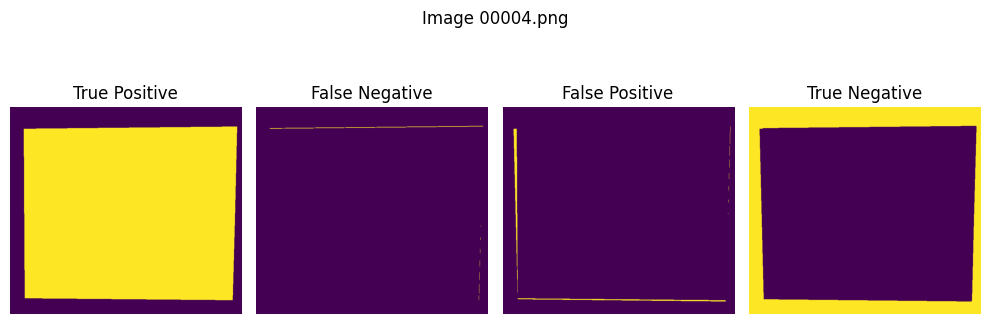

 17%|█▋        | 5/30 [00:11<01:00,  2.40s/it]

Precision: 0.9857500502939401
Recall: 0.9960080178425228
F_score: 0.9908524854445827


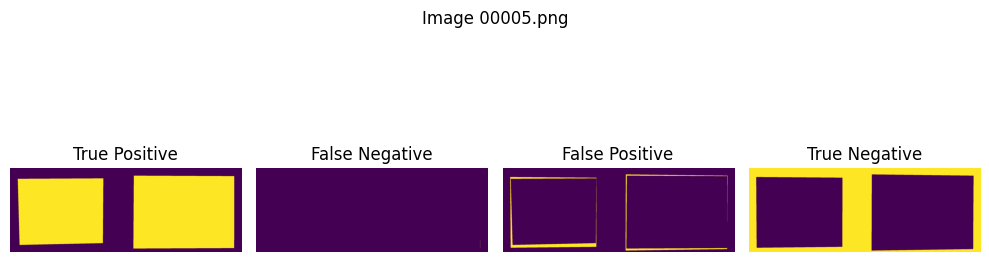

 20%|██        | 6/30 [00:16<01:19,  3.32s/it]

Precision: 0.9413470482026591
Recall: 0.9999280907199597
F_score: 0.9697536817337


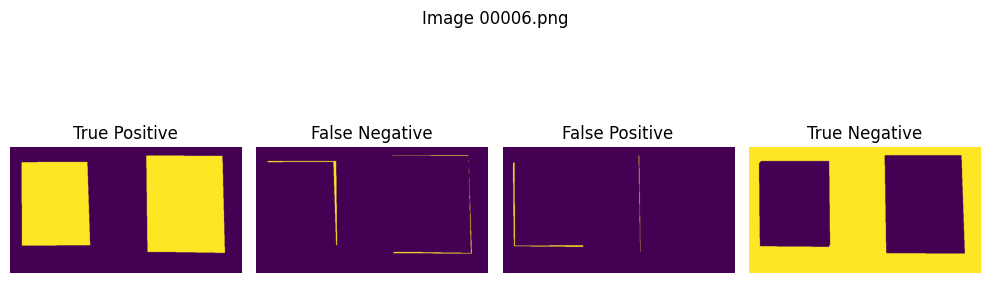

 23%|██▎       | 7/30 [00:18<01:05,  2.87s/it]

Precision: 0.9829334565878118
Recall: 0.9715707719570273
F_score: 0.9772190852822202


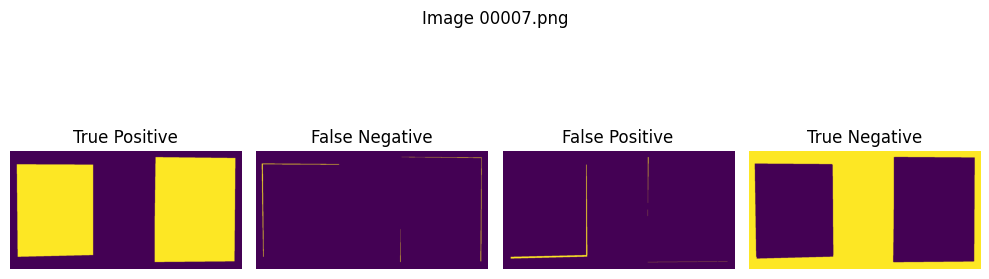

 27%|██▋       | 8/30 [00:22<01:13,  3.32s/it]

Precision: 0.9846010768477729
Recall: 0.9863932902071704
F_score: 0.985496368703041


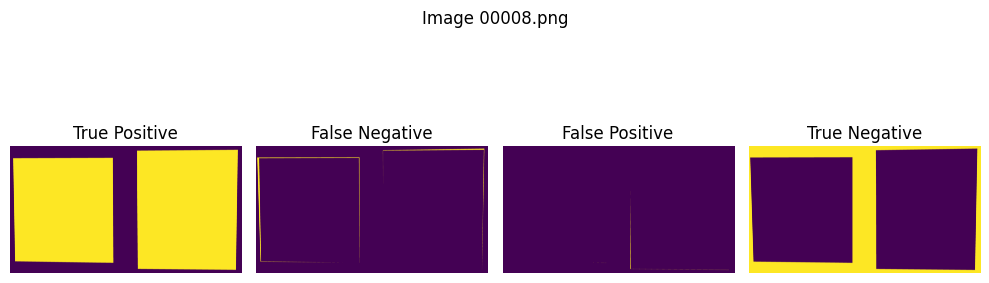

 30%|███       | 9/30 [00:43<03:03,  8.72s/it]

Precision: 0.9987422401524475
Recall: 0.9837533863939507
F_score: 0.9911911509194503


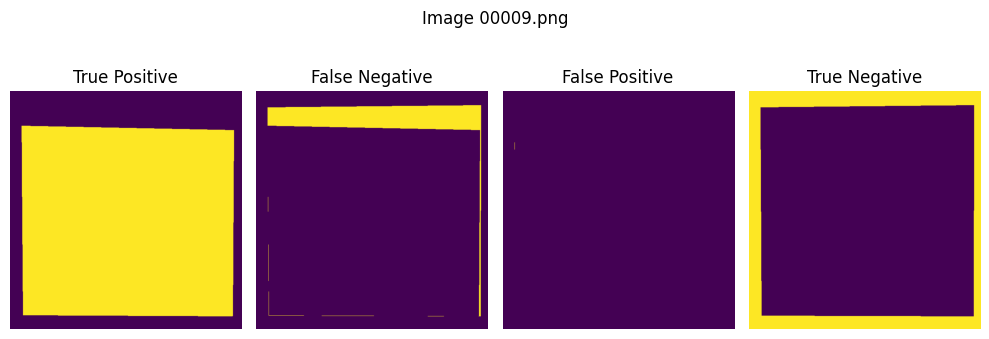

 33%|███▎      | 10/30 [00:44<02:08,  6.42s/it]

Precision: 0.9999343715750165
Recall: 0.8889504744846015
F_score: 0.9411819210889228


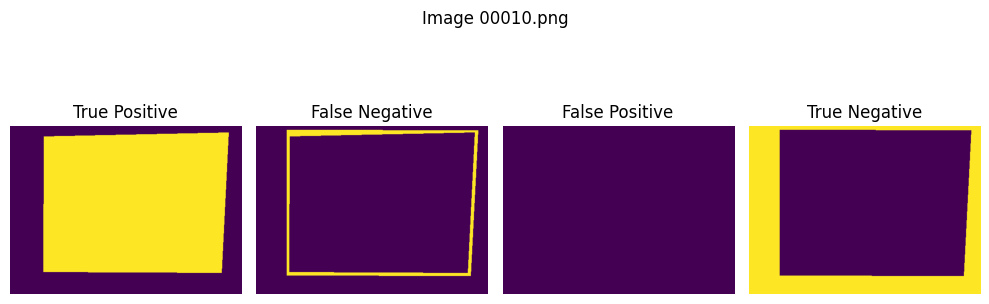

 37%|███▋      | 11/30 [00:45<01:29,  4.73s/it]

Precision: 1.0
Recall: 0.916075658426524
F_score: 0.9561998811454061


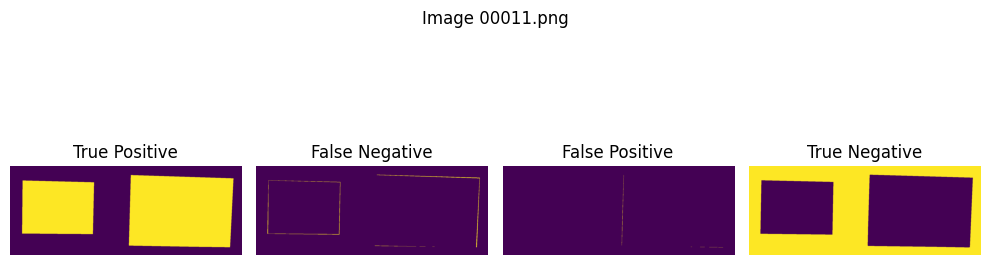

 40%|████      | 12/30 [00:49<01:23,  4.62s/it]

Precision: 0.9982938945621901
Recall: 0.983151531656835
F_score: 0.9906648535411078


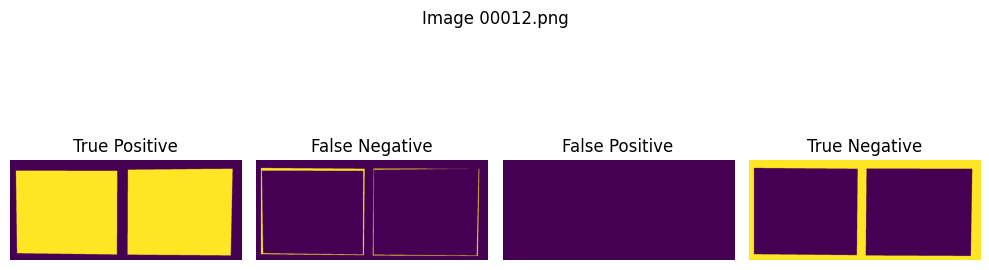

 43%|████▎     | 13/30 [00:53<01:13,  4.32s/it]

Precision: 1.0
Recall: 0.9563616738827696
F_score: 0.9776941417838032


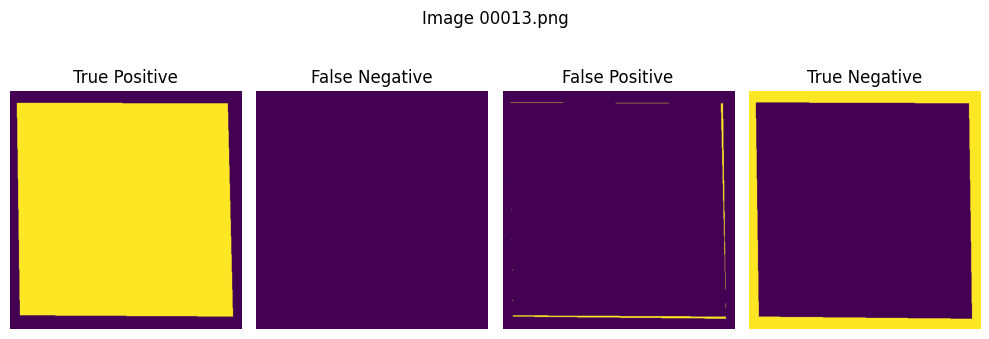

 47%|████▋     | 14/30 [00:54<00:52,  3.28s/it]

Precision: 0.9860685639688775
Recall: 0.9999959390038377
F_score: 0.9929834182850507


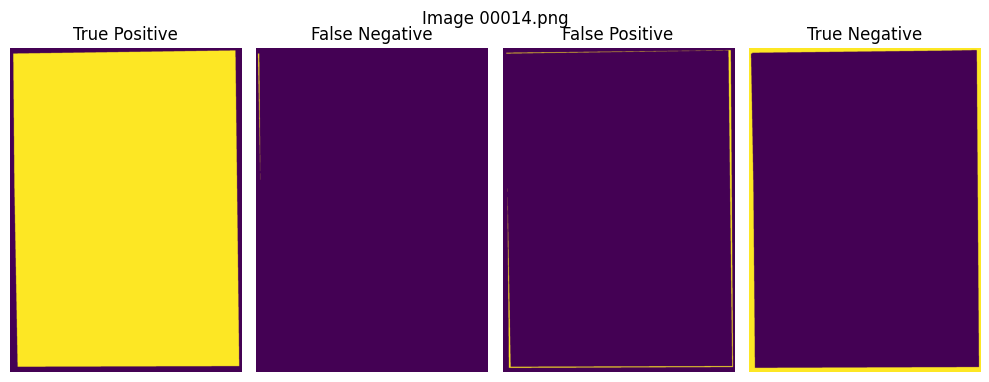

 50%|█████     | 15/30 [00:57<00:48,  3.22s/it]

Precision: 0.9863012158373686
Recall: 0.9988185570731132
F_score: 0.9925204218763901


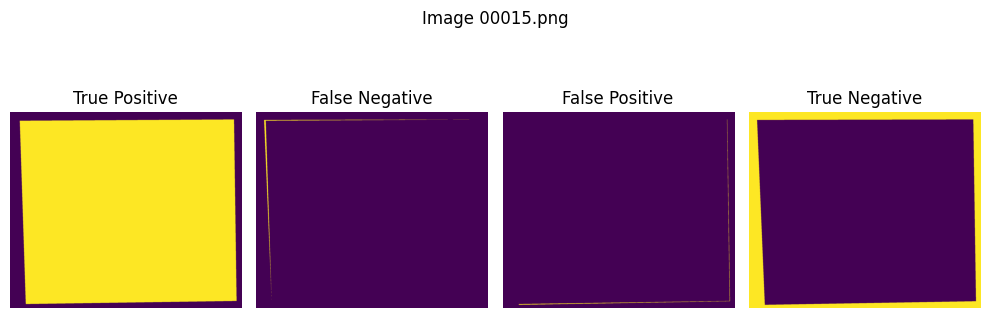

 53%|█████▎    | 16/30 [01:02<00:51,  3.69s/it]

Precision: 0.995717097766528
Recall: 0.9940581313588687
F_score: 0.9948869229846995


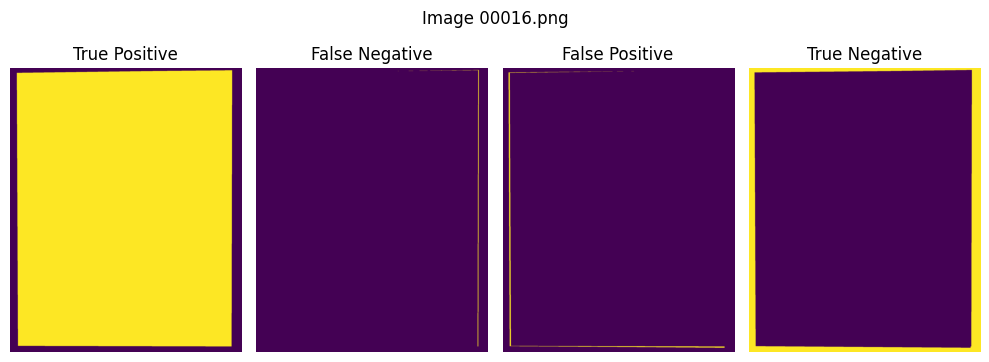

 57%|█████▋    | 17/30 [01:06<00:48,  3.75s/it]

Precision: 0.9907852847782396
Recall: 0.9964858690096032
F_score: 0.9936274006919681


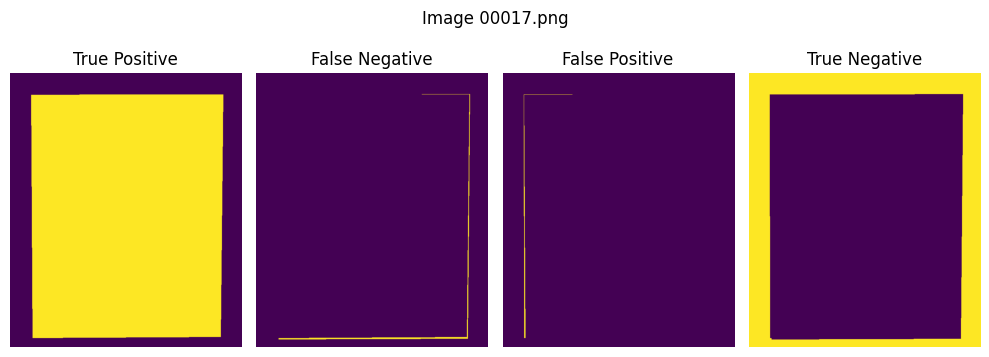

 60%|██████    | 18/30 [01:07<00:37,  3.13s/it]

Precision: 0.9949639773021228
Recall: 0.9884249260496575
F_score: 0.9916836723498563


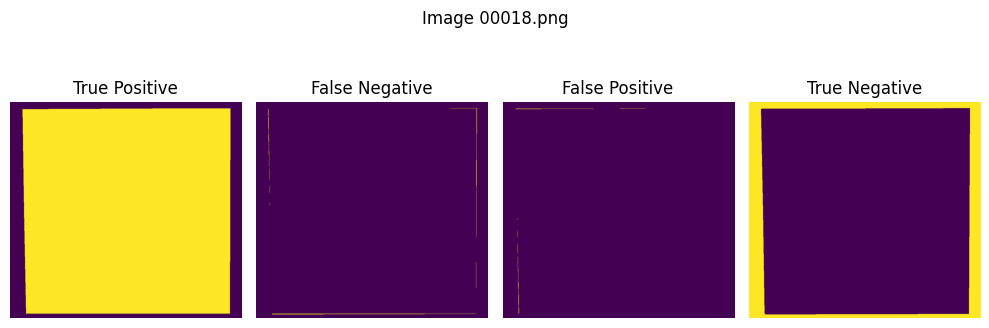

 63%|██████▎   | 19/30 [01:09<00:28,  2.63s/it]

Precision: 0.9986308555921857
Recall: 0.9955173799292718
F_score: 0.9970716872165668


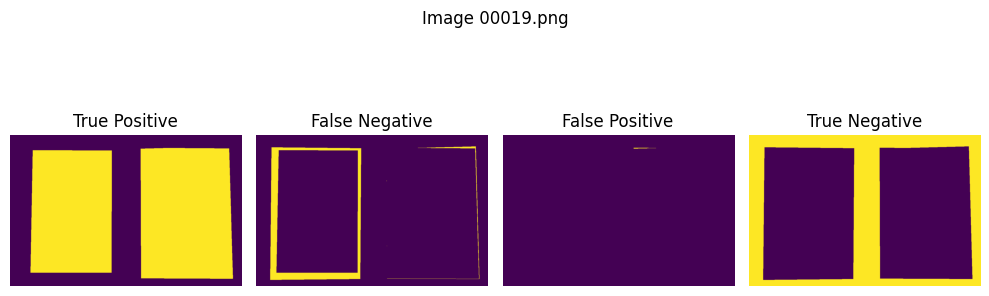

 67%|██████▋   | 20/30 [01:12<00:27,  2.71s/it]

Precision: 0.9994230200910972
Recall: 0.9074457006684796
F_score: 0.9512161092762724


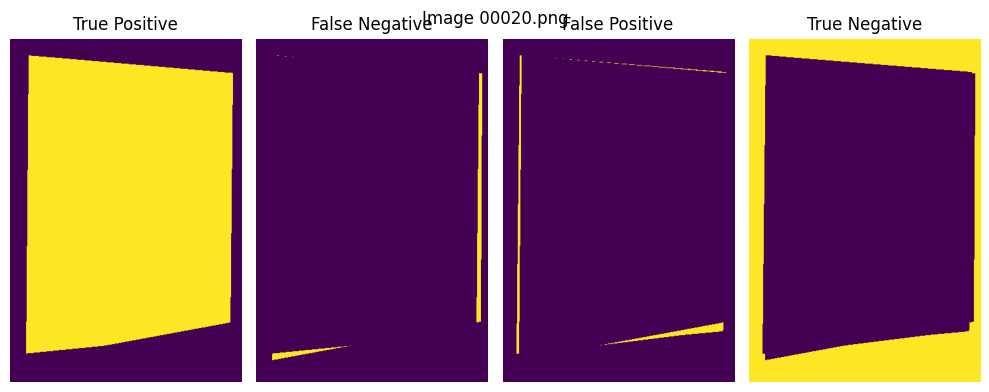

 70%|███████   | 21/30 [01:12<00:18,  2.11s/it]

Precision: 0.9781186474647121
Recall: 0.9789034069744119
F_score: 0.9785108698765502


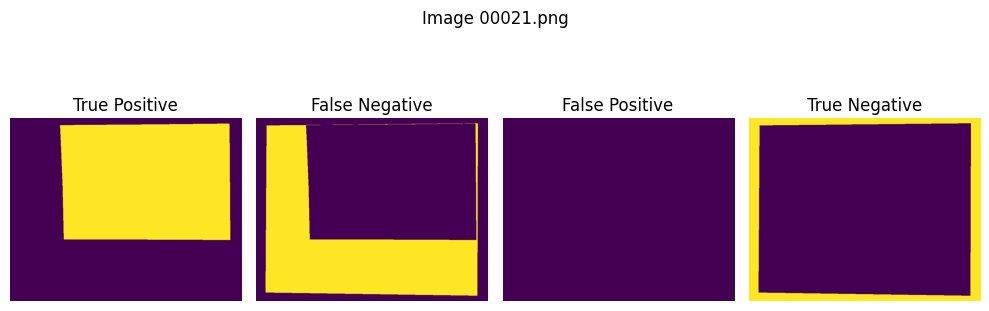

 73%|███████▎  | 22/30 [01:15<00:17,  2.24s/it]

Precision: 1.0
Recall: 0.5381167228532945
F_score: 0.6997085654917751


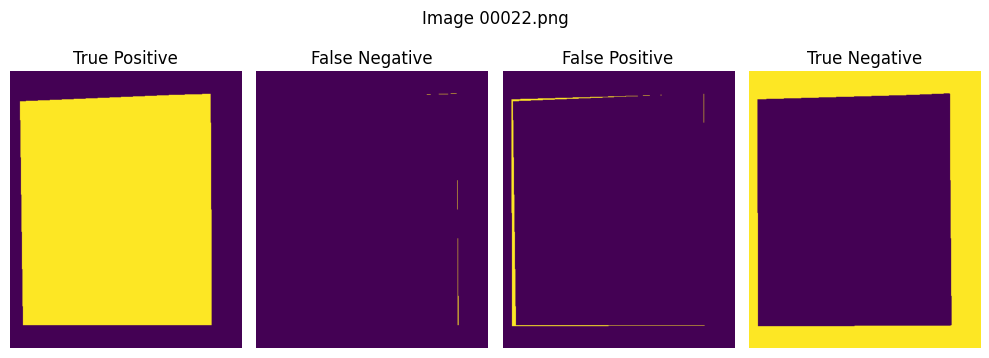

 77%|███████▋  | 23/30 [01:16<00:12,  1.85s/it]

Precision: 0.9789989988870308
Recall: 0.9981069461391965
F_score: 0.9884606371354596


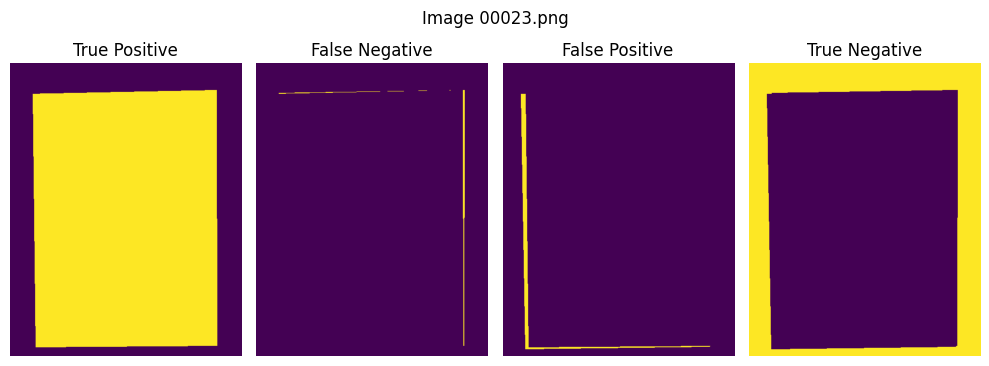

 80%|████████  | 24/30 [01:17<00:09,  1.62s/it]

Precision: 0.9726329707080429
Recall: 0.9904956141219333
F_score: 0.9814830256981267


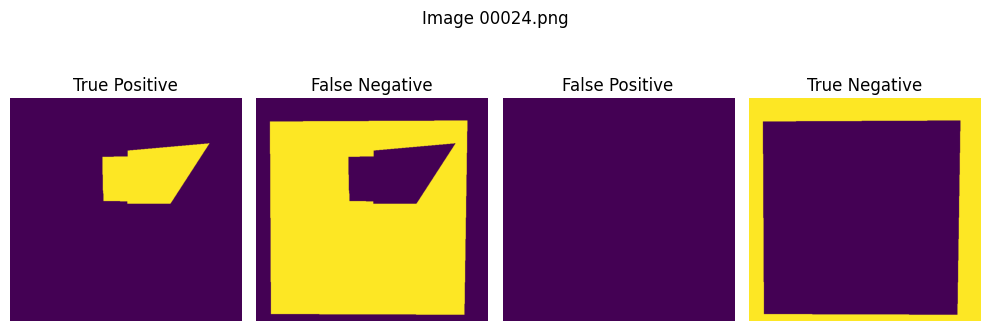

 83%|████████▎ | 25/30 [01:21<00:11,  2.37s/it]

Precision: 1.0
Recall: 0.12108150356786174
F_score: 0.21600838687021004


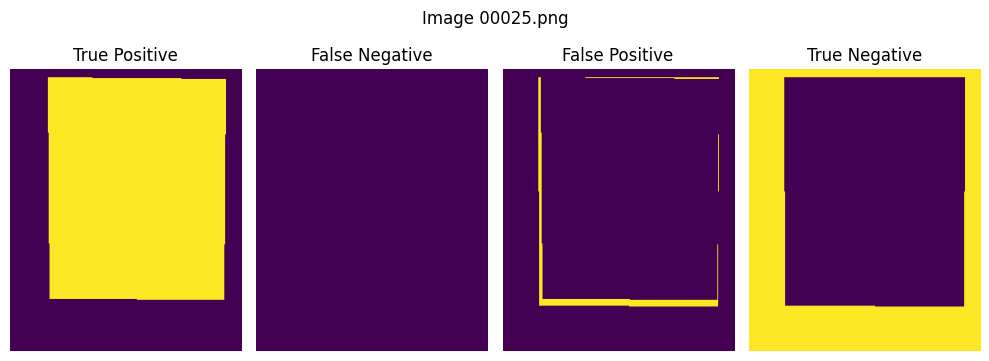

 87%|████████▋ | 26/30 [01:21<00:07,  1.82s/it]

Precision: 0.9489144973762733
Recall: 1.0
F_score: 0.9737877148061136


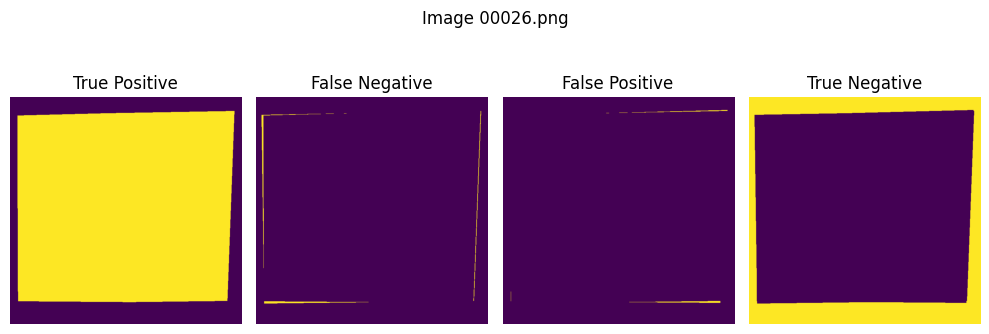

 90%|█████████ | 27/30 [01:23<00:05,  1.73s/it]

Precision: 0.9960235352441585
Recall: 0.9892607709750567
F_score: 0.9926306346131343


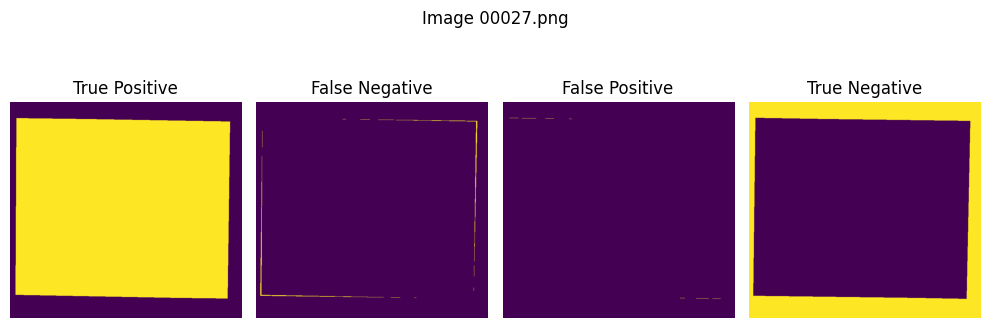

 93%|█████████▎| 28/30 [01:25<00:03,  1.68s/it]

Precision: 0.9995060757596236
Recall: 0.991222041886603
F_score: 0.9953468226127536


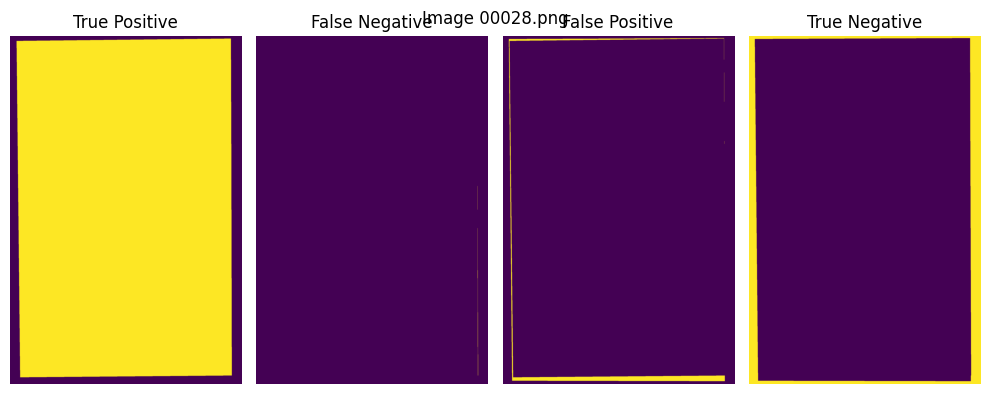

 97%|█████████▋| 29/30 [01:29<00:02,  2.52s/it]

Precision: 0.9790854036411085
Recall: 0.9995117578541588
F_score: 0.9891931434321061


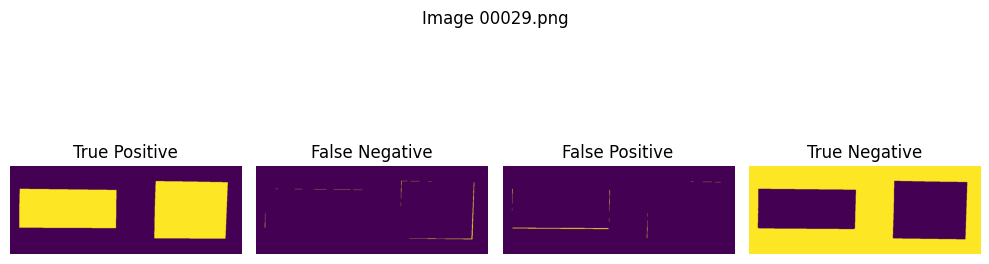

100%|██████████| 30/30 [01:32<00:00,  3.07s/it]

Precision: 0.9871090073253578
Recall: 0.9883763812437681
F_score: 0.9877422877422878
Average F_score : 0.9465632252512971
Average Precision : 0.9865785596750941
Average Recall : 0.9348138049959263


In [117]:
score = 0
precision = 0
recall = 0

for i in tqdm(range(30)):
    img = cv2.imread(f"../data/qsd2_w3/{i:05d}.jpg", cv2.IMREAD_UNCHANGED)
    if has_impulse_noise(img):
        img = cv2.medianBlur(img, 3)
    correct_img = cv2.imread(f"../data/qsd2_w3/{i:05d}.png", cv2.IMREAD_UNCHANGED)
    
    masks = get_masks(img)
    result = masks[0]
    if len(masks) > 1:
        left_mask = masks[0]
        right_mask = masks[1]
        result = np.column_stack([left_mask, right_mask])
    
    TP = np.sum(correct_img & result)
    FN = np.sum(correct_img & (255 - result))
    FP = np.sum((255 - correct_img) & result)
    TN = np.sum((255 - correct_img) & (255 - result))
    
    f, ax = plt.subplots(1, 4, figsize=(10, 8))
    f.suptitle(f"Image {i:05d}.png")
    plt.axis('off')
    ax[0].imshow(correct_img & result)
    ax[0].axis('off')
    ax[0].set_title("True Positive")
    
    ax[1].imshow(correct_img & (255 - result))
    ax[1].axis('off')
    ax[1].set_title("False Negative")
    
    ax[2].imshow((255 - correct_img) & result)
    ax[2].axis('off')
    ax[2].set_title("False Positive")
    
    ax[3].imshow((255 - correct_img) & (255 - result))
    ax[3].axis('off')
    ax[3].set_title("True Negative")
    
    plt.tight_layout(rect=[0, 0, 1, 1.5])
    
    plt.show()
    
    
    P = TP / (TP + FP)
    R = TP / (TP + FN)
    F_score = 2*(P*R/(P + R))
    
    score = score + F_score
    precision += P
    recall += R
    
    print(f"Precision: {P}\nRecall: {R}\nF_score: {F_score}")
    
print(f"Average F_score : {score/30}")
print(f"Average Precision : {precision/30}")
print(f"Average Recall : {recall/30}")